#Library Imports

In [45]:
import os
from collections import defaultdict, Counter
import pandas as pd
import seaborn as sns
from pathlib import Path
import random
from PIL import Image
import numpy as np
import xml.etree.ElementTree as ET
import umap
from scipy.special.cython_special import pdtr
import matplotlib.pyplot as plt
import umap

damage_type = ["D00", "D01", "D10", "D11", "D20", "D40", "D43", "D44"]
# damage_label =

China Exploration

In [15]:
#China_Drone - Processiong XML Files
drone_path = Path("/nfshome/data/China_Drone/train")

drone_xml_dir = drone_path / "annotations" / "xmls"
drone_xml_files = sorted(drone_xml_dir.glob("*.xml"))

all_drone_xmls =[]

# Object Extraction: https://lxml.de/tutorial.html
for file in drone_xml_files:
    tree = ET.parse(file)
    root = tree.getroot()
    filename = root.find("filename").text
    width = int(root.find("size/width").text)
    height = int(root.find("size/height").text)
    depth = int(root.find("size/depth").text)

    for obj in root.findall("object"):
        cls = obj.find("name").text
        pose = obj.find("pose").text
        truncated = int(obj.find("truncated").text)
        difficult = int(obj.find("difficult").text)
        bnd = obj.find("bndbox")
        xmin = int(bnd.find("xmin").text)
        ymin = int(bnd.find("ymin").text)
        xmax = int(bnd.find("xmax").text)
        ymax = int(bnd.find("ymax").text)

        all_drone_xmls.append(
            {
                "file": filename,
                "width": width,
                "height": height,
                "depth": depth,
                "class": cls,
                "pose": pose,
                "truncated": truncated,
                "difficult": difficult,
                "xmin": xmin,
                "ymin": ymin,
                "xmax": xmax,
                "ymax": ymax,
            }
        )

#China_Drone - Processing Image Files
drone_image_dir = drone_path / "images"
drone_images = list(drone_image_dir.glob("*.jpg"))

print(" "*20, "China_Drone Overview")
print(f"Number of Drone objects: {len(all_drone_xmls)}")
print("\nAnnotation Example:")
drone_xml_files = list({d["file"] for d in all_drone_xmls})
rand_file = random.choice(drone_xml_files)
drone_objs = [d for d in all_drone_xmls if d["file"] == rand_file]
for o in drone_objs:
    print(o)
print(f"\nNumber of Drone images: {len(drone_images)}")

                     China_Drone Overview
Number of Drone objects: 3840

Annotation Example:
{'file': 'China_Drone_000503.jpg', 'width': 512, 'height': 512, 'depth': 3, 'class': 'D40', 'pose': 'Unspecified', 'truncated': 0, 'difficult': 0, 'xmin': 133, 'ymin': 397, 'xmax': 191, 'ymax': 459}
{'file': 'China_Drone_000503.jpg', 'width': 512, 'height': 512, 'depth': 3, 'class': 'D40', 'pose': 'Unspecified', 'truncated': 1, 'difficult': 0, 'xmin': 118, 'ymin': 1, 'xmax': 160, 'ymax': 28}
{'file': 'China_Drone_000503.jpg', 'width': 512, 'height': 512, 'depth': 3, 'class': 'D40', 'pose': 'Unspecified', 'truncated': 0, 'difficult': 0, 'xmin': 406, 'ymin': 17, 'xmax': 470, 'ymax': 53}

Number of Drone images: 2401


In [16]:
#China_MotorBike Train Directory - Processing XML Files
mb_train_path = Path("/nfshome/data/China_MotorBike/train")

mb_train_xml_dir = mb_train_path / "annotations" / "xmls"
mb_train_xml_files = sorted(mb_train_xml_dir.glob("*.xml"))

all_mb_train_xmls =[]
# Object Extraction: https://lxml.de/tutorial.html
for file in mb_train_xml_files:
    tree = ET.parse(file)
    root = tree.getroot()
    filename = root.find("filename").text
    width = int(root.find("size/width").text)
    height = int(root.find("size/height").text)
    depth = int(root.find("size/depth").text)

    for obj in root.findall("object"):
        cls = obj.find("name").text
        pose = obj.find("pose").text
        truncated = int(obj.find("truncated").text)
        difficult = int(obj.find("difficult").text)
        bnd = obj.find("bndbox")
        xmin = int(bnd.find("xmin").text)
        ymin = int(bnd.find("ymin").text)
        xmax = int(bnd.find("xmax").text)
        ymax = int(bnd.find("ymax").text)

        all_mb_train_xmls.append(
            {
                "file": filename,
                "width": width,
                "height": height,
                "depth": depth,
                "class": cls,
                "pose": pose,
                "truncated": truncated,
                "difficult": difficult,
                "xmin": xmin,
                "ymin": ymin,
                "xmax": xmax,
                "ymax": ymax,
            }
        )

# China_MotorBike Train Directory - Processing Image Files
mb_train_image_dir = mb_train_path / "images"
mb_train_images = list(mb_train_image_dir.glob("*.jpg"))

#China_Motorbike Test Directory - Processing Image Files
mb_test_path = Path("/nfshome/data/China_MotorBike/test")
mb_test_image_dir = mb_test_path / "images"
mb_test_images = list(mb_test_image_dir.glob("*.jpg"))

print(" "*20, "China_MotorBike Overview")
print(f"Number of MotorBike objects: {len(all_mb_train_xmls)}")
print("\nAnnotation Example:")
mb_train_files = list({d["file"] for d in all_mb_train_xmls})
rand_file = random.choice(mb_train_files)
mb_train_objs = [d for d in all_mb_train_xmls if d["file"] == rand_file]
for o in mb_train_objs:
    print(o)
print(f"\nNumber of MotorBike images in train directory: {len(mb_train_images)}")
print(f"Number of MotorBike images in test directory: {len(mb_test_images)}")
print(f"Total MotorBike images: {(len(mb_train_images) + len(mb_test_images))}")


                     China_MotorBike Overview
Number of MotorBike objects: 4927

Annotation Example:
{'file': 'China_MotorBike_000147.jpg', 'width': 512, 'height': 512, 'depth': 3, 'class': 'D10', 'pose': 'Unspecified', 'truncated': 1, 'difficult': 0, 'xmin': 1, 'ymin': 342, 'xmax': 509, 'ymax': 442}
{'file': 'China_MotorBike_000147.jpg', 'width': 512, 'height': 512, 'depth': 3, 'class': 'D00', 'pose': 'Unspecified', 'truncated': 0, 'difficult': 0, 'xmin': 287, 'ymin': 262, 'xmax': 394, 'ymax': 351}
{'file': 'China_MotorBike_000147.jpg', 'width': 512, 'height': 512, 'depth': 3, 'class': 'D00', 'pose': 'Unspecified', 'truncated': 0, 'difficult': 0, 'xmin': 112, 'ymin': 281, 'xmax': 280, 'ymax': 351}
{'file': 'China_MotorBike_000147.jpg', 'width': 512, 'height': 512, 'depth': 3, 'class': 'D10', 'pose': 'Unspecified', 'truncated': 1, 'difficult': 0, 'xmin': 396, 'ymin': 232, 'xmax': 512, 'ymax': 279}

Number of MotorBike images in train directory: 1977
Number of MotorBike images in test d

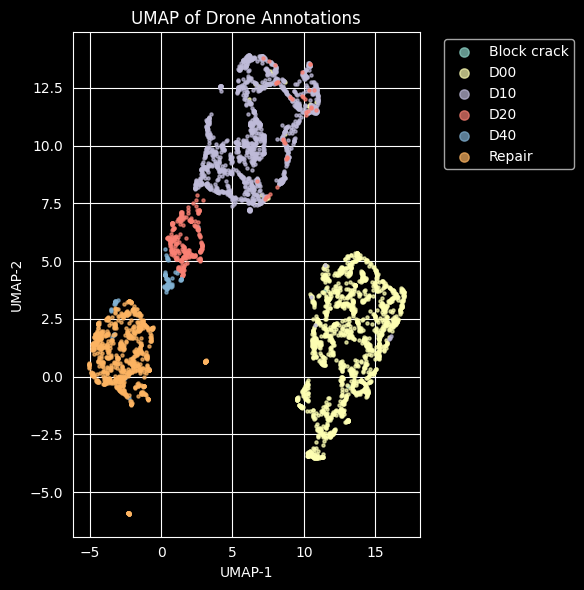

In [29]:
# Visualization for China_Drone and China_MotorBike
df = pd.DataFrame(all_drone_xmls)

df["box_w"] = df["xmax"] - df["xmin"]
df["box_h"] = df["ymax"] - df["ymin"]
df["range_xmin"] = df["xmin"] / df["width"]
df["range_ymin"] = df["ymin"] / df["height"]
df["range_box_w"] = df["box_w"] / df["width"]
df["range_box_h"] = df["box_h"] / df["height"]

class_convert_id = {c: i for i, c in enumerate(sorted(df["class"].unique()))}
df["class_id"] = df["class"].map(class_convert_id)

features = df[["range_xmin", "range_ymin", "range_box_w", "range_box_h", "class_id"]].values

scaled = StandardScaler().fit_transform(features)

reducer = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    n_components=2
)

embedding = reducer.fit_transform(scaled)
df["umap_x"] = embedding[:, 0]
df["umap_y"] = embedding[:, 1]

plt.figure(figsize=(6, 6))
for cls, sub in df.groupby("class"):
    plt.scatter(sub["umap_x"], sub["umap_y"], s=5, alpha=0.7, label=cls)

plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.title("UMAP of Drone Annotations")
plt.legend(markerscale=3, bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()
print("Clusters show D00 is perpendicular from the rest of the classes.\nD10 and D20 have similar locations and sizes.\nWith Repair more closely related to D20, D40, and D10")

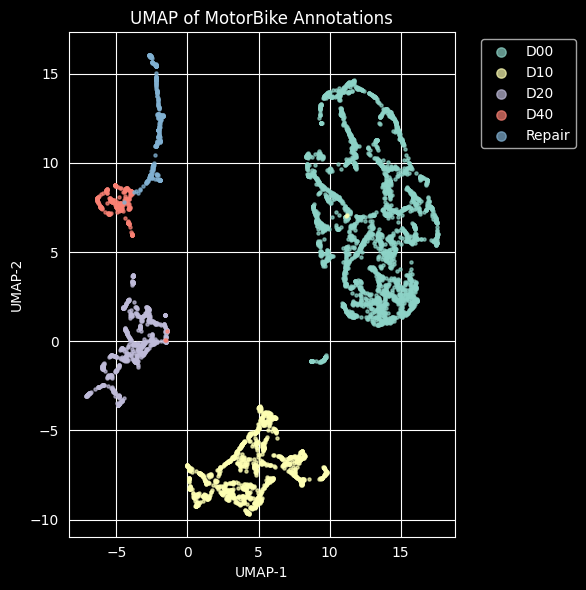

Clusters show D00 and D10 greatly differ from the other classes. 
D40 and repair have similar locations and sizes.



In [33]:
# Visualization for China_Drone and China_MotorBike
df = pd.DataFrame(all_mb_train_xmls)

df["box_w"] = df["xmax"] - df["xmin"]
df["box_h"] = df["ymax"] - df["ymin"]
df["range_xmin"] = df["xmin"] / df["width"]
df["range_ymin"] = df["ymin"] / df["height"]
df["range_box_w"] = df["box_w"] / df["width"]
df["range_box_h"] = df["box_h"] / df["height"]

class_convert_id = {c: i for i, c in enumerate(sorted(df["class"].unique()))}
df["class_id"] = df["class"].map(class_convert_id)

features = df[["range_xmin", "range_ymin", "range_box_w", "range_box_h", "class_id"]].values

scaled = StandardScaler().fit_transform(features)

reducer = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    n_components=2
)

embedding = reducer.fit_transform(scaled)
df["umap_x"] = embedding[:, 0]
df["umap_y"] = embedding[:, 1]

plt.figure(figsize=(6, 6))
for cls, sub in df.groupby("class"):
    plt.scatter(sub["umap_x"], sub["umap_y"], s=5, alpha=0.7, label=cls)

plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.title("UMAP of MotorBike Annotations")
plt.legend(markerscale=3, bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()
print("Clusters show D00 and D10 greatly differ from the other classes. \nD40 and Repair have similar locations and sizes. With D20 having similar locations and sizes as D40\n")

In [ ]:
#Czech Exploration

In [44]:
#Czech Train Directory - Processiong XML Files
czech_train_path = Path("/nfshome/data/Czech/train")

czech_train_xml_dir = czech_train_path / "annotations" / "xmls"
czech_train_xml_files = sorted(czech_train_xml_dir.glob("*.xml"))

all_czech_train_xmls =[]

# Object Extraction: https://lxml.de/tutorial.html
for file in czech_train_xml_files:
    tree = ET.parse(file)
    root = tree.getroot()
    filename = root.find("filename").text
    width = int(root.find("size/width").text)
    height = int(root.find("size/height").text)
    depth = int(root.find("size/depth").text)

    for obj in root.findall("object"):
        cls = obj.find("name").text
        pose = obj.findtext("pose", default="uknown")
        #Need to fix error below here.
        truncated = int(obj.findtext("truncated",default="uknown"))
        difficult = int(obj.find("difficult").text)
        bnd = obj.find("bndbox")
        xmin = int(bnd.find("xmin").text)
        ymin = int(bnd.find("ymin").text)
        xmax = int(bnd.find("xmax").text)
        ymax = int(bnd.find("ymax").text)

        all_czech_train_xmls.append(
            {
                "file": filename,
                "width": width,
                "height": height,
                "depth": depth,
                "class": cls,
                "pose": pose,
                "truncated": truncated,
                "difficult": difficult,
                "xmin": xmin,
                "ymin": ymin,
                "xmax": xmax,
                "ymax": ymax,
            }
        )

#Czech Train Directory - Processing Image Files
czech_train_image_dir = czech_train_path / "images"
czech_train_images = list(czech_train_image_dir.glob("*.jpg"))

#Czech Test Directory - Processing Image Files
czech_test_path = Path("/nfshome/data/Czech/test")
czech_test_image_dir = czech_test_path / "images"
czech_test_images = list(czech_test_image_dir.glob("*.jpg"))

print(" "*20, "Czech Overview")
print(f"Number of Czech objects: {len(all_czech_train_xmls)}")
print("\nAnnotation Example:")
czech_train_xml_files = list({d["file"] for d in all_czech_train_xmls})
rand_file = random.choice(czech_train_xml_files)
czech_train_objs = [d for d in all_czech_train_xmls if d["file"] == rand_file]
for o in czech_train_objs:
    print(o)

print(f"\nNumber of Czech images in train directory: {len(czech_train_images)}")
print(f"Number of Czech images in test directory: {len(czech_test_images)}")
print(f"Total Czech images: {(len(czech_train_images) + len(czech_test_images))}")

AttributeError: 'NoneType' object has no attribute 'text'